## 4. Absorption as the Functional Mechanism

### Question: To what extent does a high score in the "Absorption MODTAS" construct predict a participant's chills_ability?

Why it’s essential: This specifically evaluates the Construct you added. If the MODTAS (Absorption) scores are significantly higher for the chills group, you’ve identified the likely "cognitive engine" behind the physical response. This is a crucial validation step for the survey instrument itself.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from matplotlib.colors import LinearSegmentedColormap

In [3]:
df = pd.read_excel('cleaned_responses_update.xlsx', sheet_name='cleanedAweExperienceSurveyRespo')

df.columns

Index(['timestamp', 'age_range', 'env_growth', 'worldview', 'activity_primary',
       'regular_practices', 'household_size', 'gender_assigned',
       'gender_identity', 'edu_level', 'income_bracket', 'socioec_status',
       'college_name', 'awe_scale_1', 'awe_scale_2', 'awe_scale_3',
       'awe_scale_4', 'awe_scale_5', 'awe_scale_6', 'awe_scale_7',
       'awe_scale_8', 'awe_scale_9', 'awe_scale_10', 'awe_scale_11',
       'awe_scale_12', 'control', 'trigger_moved_1', 'trigger_moved_2',
       'trigger_moved_3', 'trigger_moved_4', 'trigger_moved_5',
       'trigger_moved_6', 'trigger_moved_7', 'trigger_moved_8',
       'trigger_moved_9', 'trigger_moved_10', 'trigger_phys_1',
       'trigger_phys_2', 'trigger_phys_3', 'trigger_phys_4', 'trigger_phys_5',
       'trigger_phys_6', 'trigger_phys_7', 'trigger_phys_8', 'trigger_phys_9',
       'trigger_interpersonal_1', 'trigger_interpersonal_2',
       'trigger_interpersonal_3', 'trigger_interpersonal_4',
       'trigger_interpersonal_5'

In [4]:
colors = ['#00C2AE', '#40E3C8', '#74E8BF',
          '#A4EDBC', '#C7F0B9', '#74E8BF', '#40E3C8']

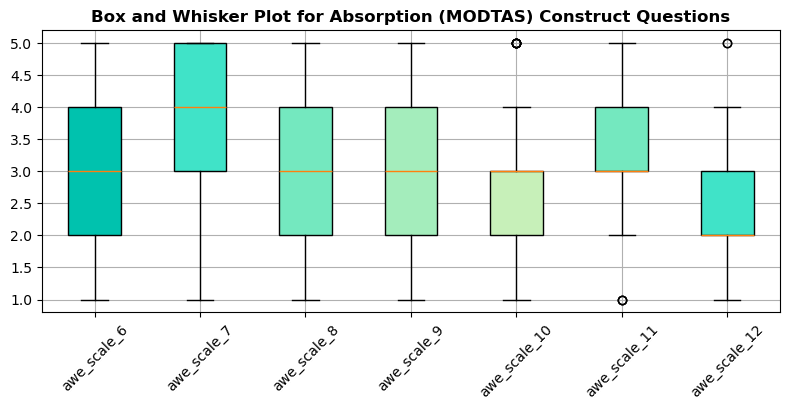

The average value for an answer to the Absorption construct questions was 3.05.


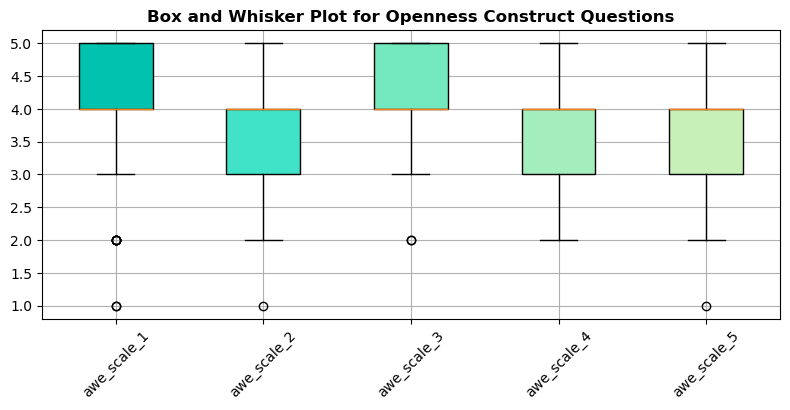

The average value for an answer to the Openness construct questions was 3.92.


In [5]:
absorp_df = df[['awe_scale_6', 'awe_scale_7', 'awe_scale_8', 'awe_scale_9', 'awe_scale_10', 'awe_scale_11', 'awe_scale_12', 'chills_ability']]
absorp_df = absorp_df.dropna()

absorp_data = absorp_df.drop(['chills_ability'], axis=1)

#creating a box and whisker plot for the absoprtion construct
fig, ax = plt.subplots(figsize=(8,4))

bp = ax.boxplot(absorp_data.values, patch_artist=True)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_xticklabels(absorp_data.columns, rotation=45)
plt.tight_layout()
plt.title('Box and Whisker Plot for Absorption (MODTAS) Construct Questions', fontsize=12, fontweight='bold')
plt.grid()
plt.show()

#finding the average value for all the absoprtion questions
average_absorp = absorp_data.select_dtypes(include='number').mean().mean()

print(f'The average value for an answer to the Absorption construct questions was {average_absorp:.2f}.')

#assigning a df and removing NA values for the openness construct
open_df = df[['awe_scale_1', 'awe_scale_2', 'awe_scale_3', 'awe_scale_4', 'awe_scale_5', 'chills_ability']]
open_df = open_df.dropna()
open_data = open_df.drop(['chills_ability'], axis=1)

#creating a box and whisker plot for the openness construct
fig, ax = plt.subplots(figsize=(8,4))

bp = ax.boxplot(open_data.values, patch_artist=True)

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)

ax.set_xticklabels(open_data.columns, rotation=45)
plt.tight_layout()
plt.title('Box and Whisker Plot for Openness Construct Questions', fontsize=12, fontweight='bold')
plt.grid()
plt.show()

#finding the average value for all the openness questions
average_open = open_data.select_dtypes(include='number').mean().mean()

print(f'The average value for an answer to the Openness construct questions was {average_open:.2f}.')



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
#What is the predictability from chills for the Absorption construct?
X = absorp_df.drop(['chills_ability'], axis=1)
y = absorp_df['chills_ability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accurary:', accuracy_score(y_test, predictions))

Accurary: 0.35


In [8]:
#running the same model with a different random state for the train test split to verify how accuracy changes. 
X = absorp_df.drop(['chills_ability'], axis=1)
y = absorp_df['chills_ability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accurary:', accuracy_score(y_test, predictions))


Accurary: 0.65


In [9]:
#running the same model with a different random state for the train test split to verify how accuracy changes. 
X = absorp_df.drop(['chills_ability'], axis=1)
y = absorp_df['chills_ability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accurary:', accuracy_score(y_test, predictions))

Accurary: 0.8


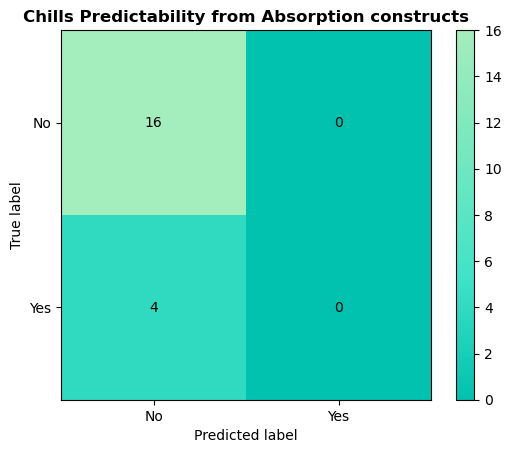

              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89        16
         1.0       0.00      0.00      0.00         4

    accuracy                           0.80        20
   macro avg       0.40      0.50      0.44        20
weighted avg       0.64      0.80      0.71        20



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
#using the model for the opennuess construct with the highest accuracy score - a confusion matrix was run

custom_cmap = LinearSegmentedColormap.from_list('custom', ['#00C2AE', '#40E3C8', '#74E8BF', '#A4EDBC'])

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['No', 'Yes'], cmap=custom_cmap)
plt.title('Chills Predictability from Absorption constructs', fontsize=12, fontweight='bold')
for text in disp.text_.ravel():
    text.set_color('black')
plt.show()

print(classification_report(y_test, predictions))

## Openness Construct

In [12]:
#What is the predictability for chills from the Openess Construct? 
X = open_df.drop(['chills_ability'], axis=1)
y = open_df['chills_ability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accurary:', accuracy_score(y_test, predictions))


Accurary: 0.65


In [13]:
#running the same model with a different random state for the train test split to verify how accuracy changes. 
X = open_df.drop(['chills_ability'], axis=1)
y = open_df['chills_ability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accurary:', accuracy_score(y_test, predictions))

Accurary: 0.6


In [14]:
#running the same model with a different random state for the train test split to verify how accuracy changes. 
X = open_df.drop(['chills_ability'], axis=1)
y = open_df['chills_ability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=57)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print('Accurary:', accuracy_score(y_test, predictions))

Accurary: 0.75


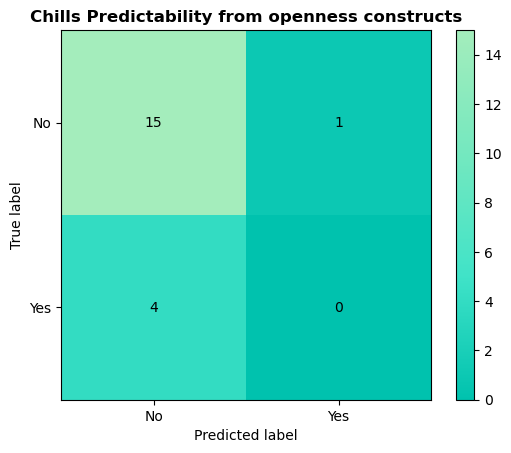

              precision    recall  f1-score   support

         0.0       0.79      0.94      0.86        16
         1.0       0.00      0.00      0.00         4

    accuracy                           0.75        20
   macro avg       0.39      0.47      0.43        20
weighted avg       0.63      0.75      0.69        20



In [15]:
#using the model for the opennuess construct with the highest accuracy score - a confusion matrix was run

custom_cmap = LinearSegmentedColormap.from_list('custom', ['#00C2AE', '#40E3C8', '#74E8BF', '#A4EDBC'])

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['No', 'Yes'], cmap=custom_cmap)
plt.title('Chills Predictability from openness constructs', fontsize=12, fontweight='bold')
for text in disp.text_.ravel():
    text.set_color('black')
plt.show()

print(classification_report(y_test, predictions))